In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import joblib

In [2]:
# Load dataset
data = load_digits()
X = data.data
y = data.target

In [3]:
X

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [4]:
y

array([0, 1, 2, ..., 8, 9, 8])

In [5]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

In [7]:
# Train model
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

In [8]:
# 6. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# 7. Save Model
joblib.dump(pipeline, "ml_pipeline_model.pkl")

print("Model saved as ml_pipeline_model.pkl")

Accuracy : 0.9722222222222222
Precision: 0.9725212596953555
Recall   : 0.9722222222222222
F1 Score : 0.9722963303758159
Model saved as ml_pipeline_model.pkl


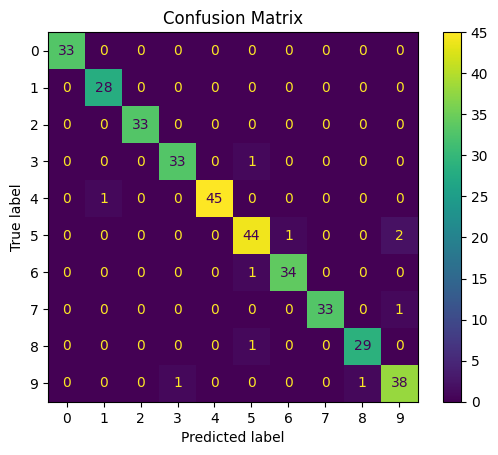

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test)
plt.title("Confusion Matrix")
plt.show()

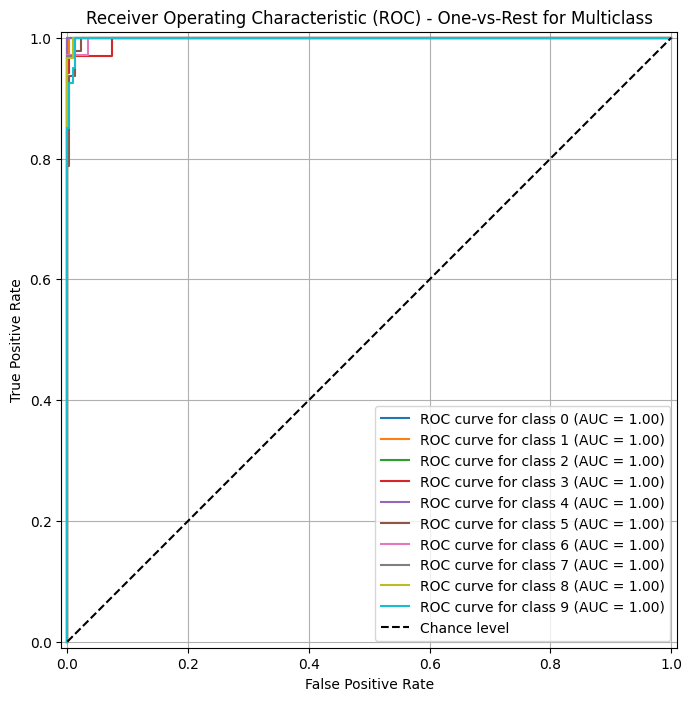

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize

# Get the number of classes from the pipeline's model
num_classes = len(pipeline.named_steps['model'].classes_)

# Binarize the true labels for one-vs-rest strategy
y_test_binarized = label_binarize(y_test, classes=range(num_classes))

# Get the predicted probabilities for each class
y_score = pipeline.predict_proba(X_test)

# Create a figure for the ROC curves
plt.figure(figsize=(10, 8))

# Plot ROC curve for each class
for i in range(num_classes):
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, i],       # True binary labels for current class
        y_score[:, i],               # Predicted probabilities for current class
        name=f"ROC curve for class {i}",
        ax=plt.gca(),                # Plot on the current axes
        plot_chance_level=False      # Do not plot chance level for each individual curve
    )

plt.plot([0, 1], [0, 1], 'k--', label='Chance level') # Plot overall chance level
plt.title('Receiver Operating Characteristic (ROC) - One-vs-Rest for Multiclass')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()